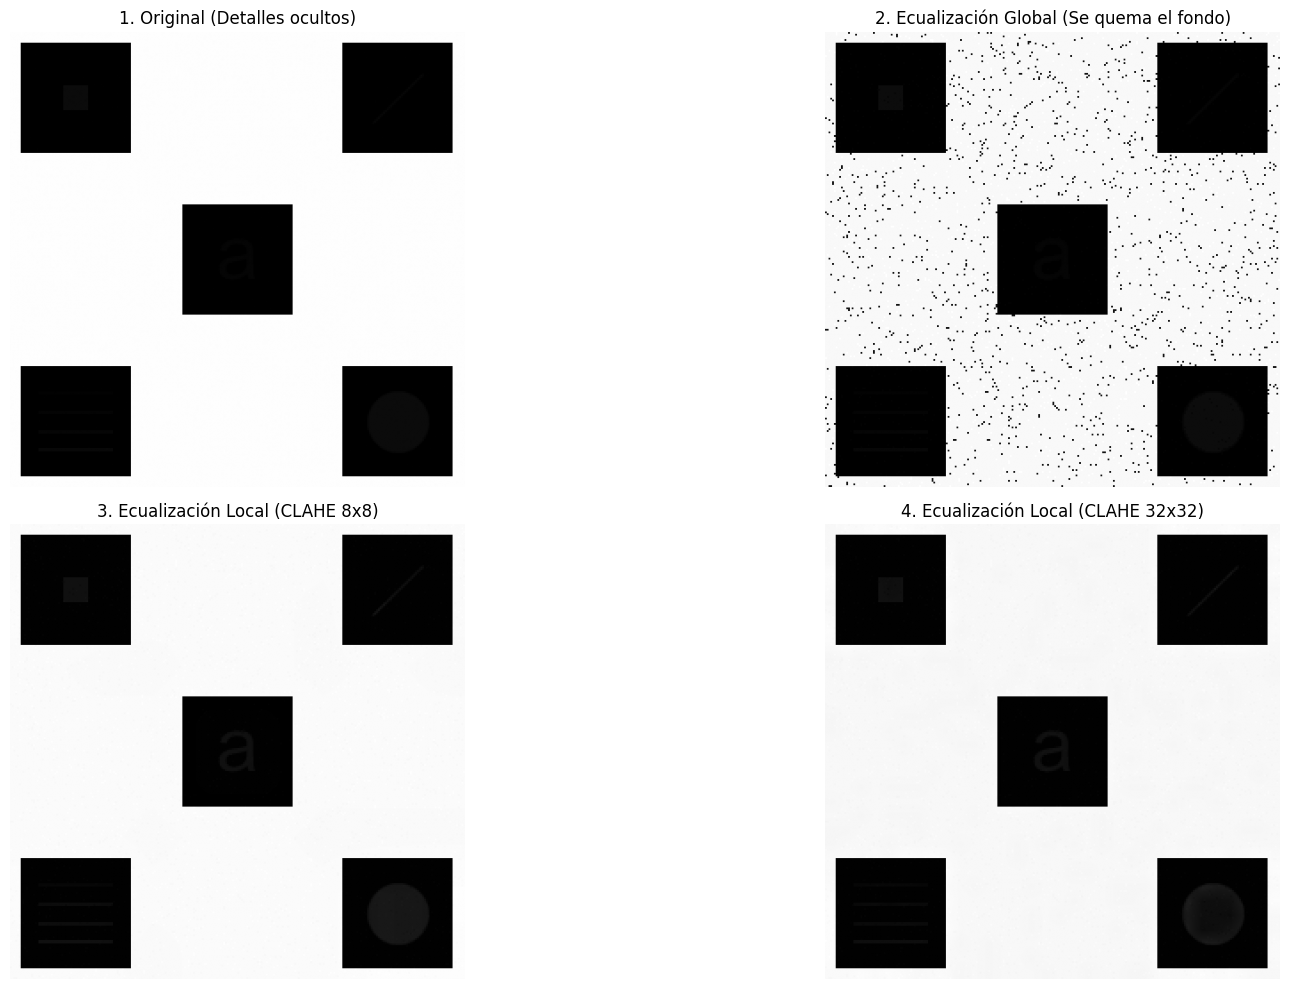

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os

# 1. Cargar la imagen cuadros.tif en escala de grises
# Ajustá la ruta según tu carpeta de imágenes
ruta_cuadros = '../../imagenes/cuadros.tif'
img_cuadros = cv2.imread(ruta_cuadros, cv2.IMREAD_GRAYSCALE)

if img_cuadros is None:
    print("Error: No se encontró la imagen")
else:
    # 2. Ecualización Global
    img_global = cv2.equalizeHist(img_cuadros)

    # 3. Ecualización Local (CLAHE)
    # tileGridSize es el tamaño de la ventana. Probamos con 8x8 y 32x32 para comparar
    clahe_8 = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img_local_8 = clahe_8.apply(img_cuadros)
    
    clahe_32 = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(32, 32))
    img_local_32 = clahe_32.apply(img_cuadros)

    # 4. Mostrar Resultados
    plt.figure(figsize=(20, 10))

    plt.subplot(2, 2, 1)
    plt.imshow(img_cuadros, cmap='gray')
    plt.title('1. Original (Detalles ocultos)')
    plt.axis('off')

    plt.subplot(2, 2, 2)
    plt.imshow(img_global, cmap='gray')
    plt.title('2. Ecualización Global (Se quema el fondo)')
    plt.axis('off')

    plt.subplot(2, 2, 3)
    plt.imshow(img_local_8, cmap='gray')
    plt.title('3. Ecualización Local (CLAHE 8x8)')
    plt.axis('off')

    plt.subplot(2, 2, 4)
    plt.imshow(img_local_32, cmap='gray')
    plt.title('4. Ecualización Local (CLAHE 32x32)')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

Se encontraron 15 imágenes para procesar.



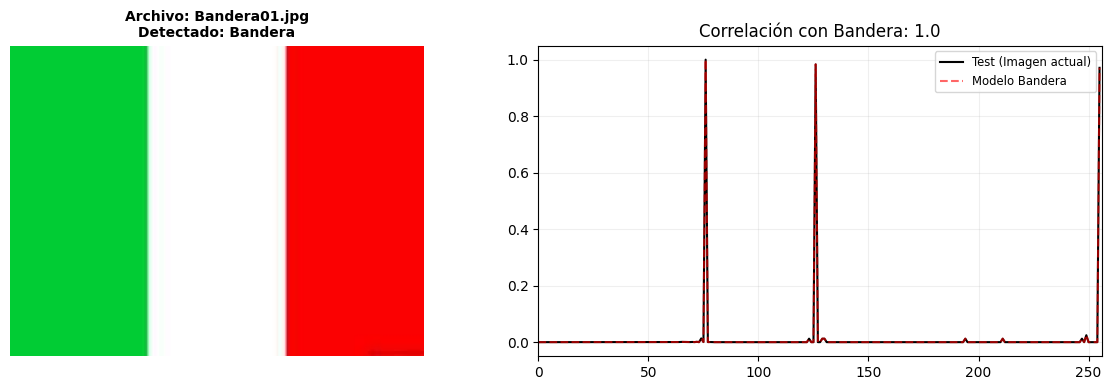

Puntajes para Bandera01.jpg: {'Bandera': 1.0, 'Caricaturas': 0.1111, 'Paisaje': -0.0405, 'Personaje': -0.022}
------------------------------------------------------------


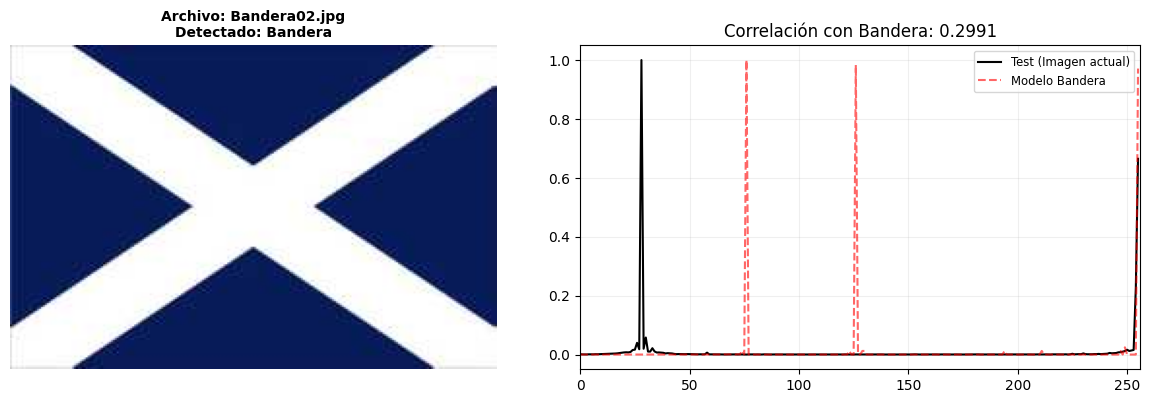

Puntajes para Bandera02.jpg: {'Bandera': 0.2991, 'Caricaturas': 0.2761, 'Paisaje': -0.0828, 'Personaje': -0.0168}
------------------------------------------------------------


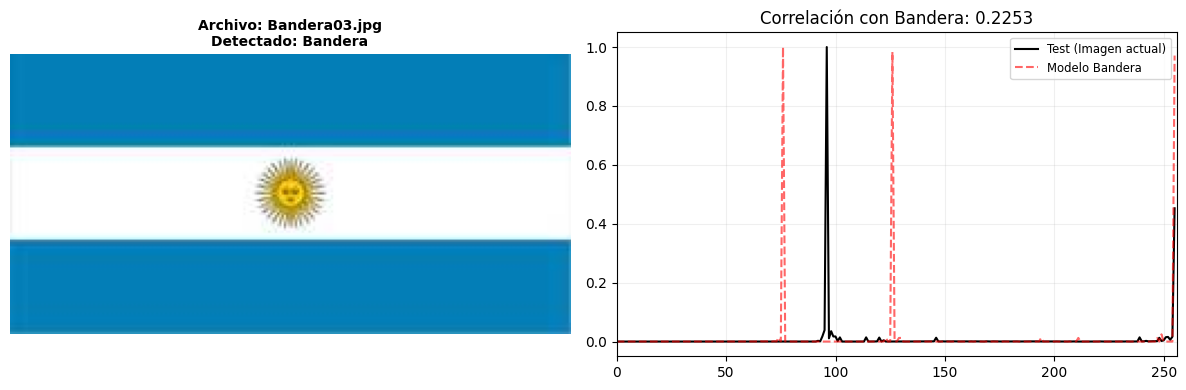

Puntajes para Bandera03.jpg: {'Bandera': 0.2253, 'Caricaturas': 0.102, 'Paisaje': -0.032, 'Personaje': -0.0163}
------------------------------------------------------------


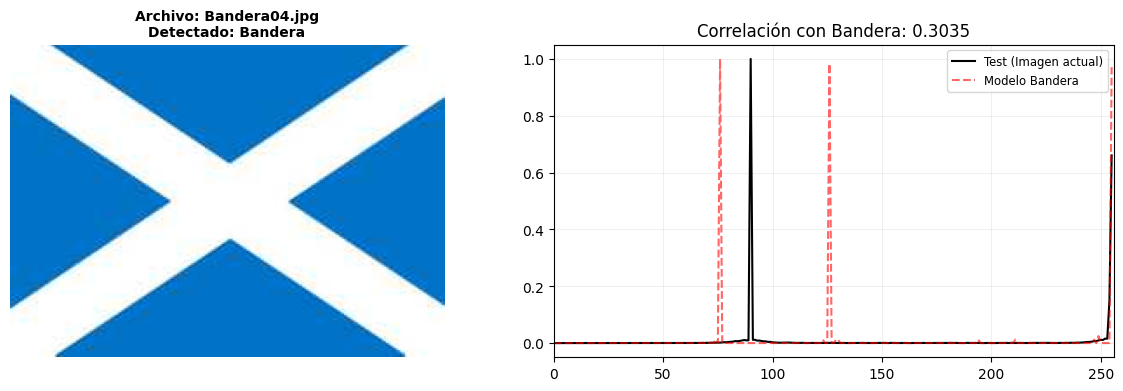

Puntajes para Bandera04.jpg: {'Bandera': 0.3035, 'Caricaturas': 0.2323, 'Paisaje': -0.0395, 'Personaje': -0.0197}
------------------------------------------------------------


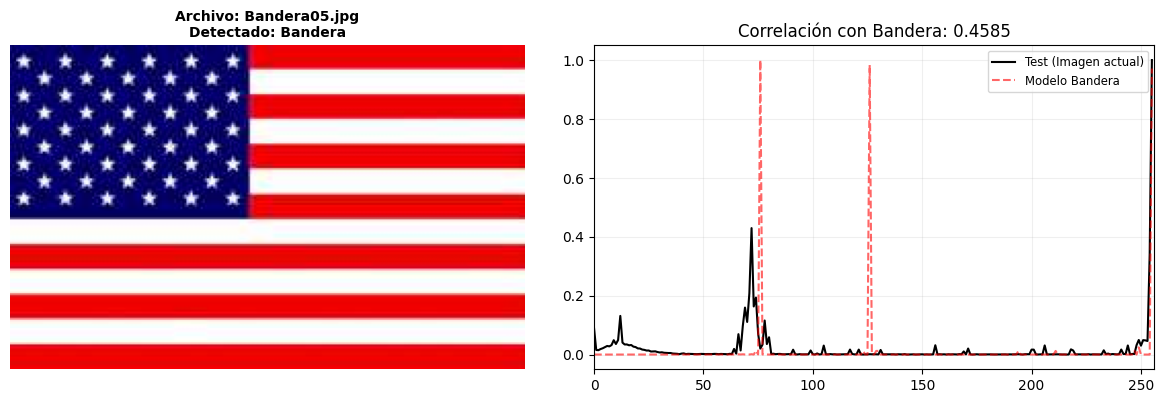

Puntajes para Bandera05.jpg: {'Bandera': 0.4585, 'Caricaturas': 0.4215, 'Paisaje': -0.1083, 'Personaje': 0.0112}
------------------------------------------------------------


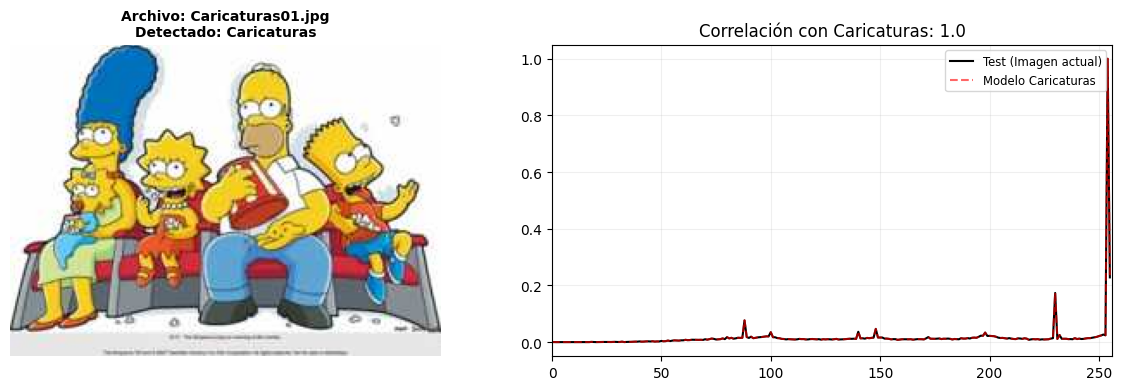

Puntajes para Caricaturas01.jpg: {'Bandera': 0.1111, 'Caricaturas': 1.0, 'Paisaje': -0.0119, 'Personaje': -0.0434}
------------------------------------------------------------


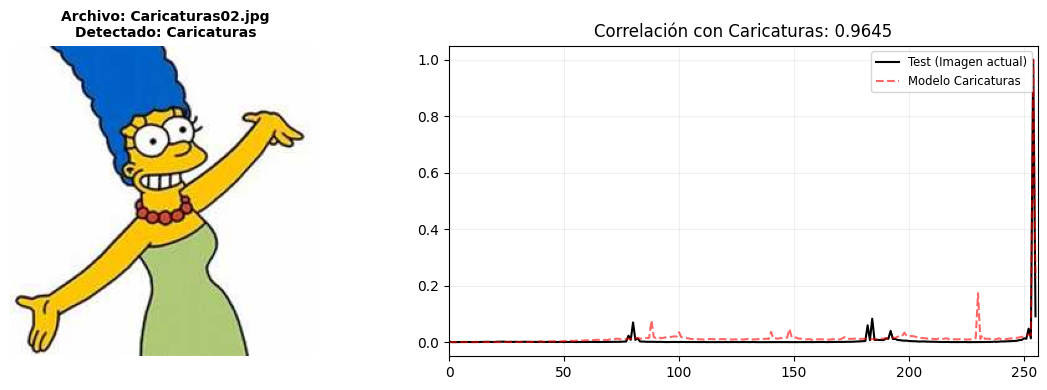

Puntajes para Caricaturas02.jpg: {'Bandera': 0.0405, 'Caricaturas': 0.9645, 'Paisaje': -0.0026, 'Personaje': -0.022}
------------------------------------------------------------


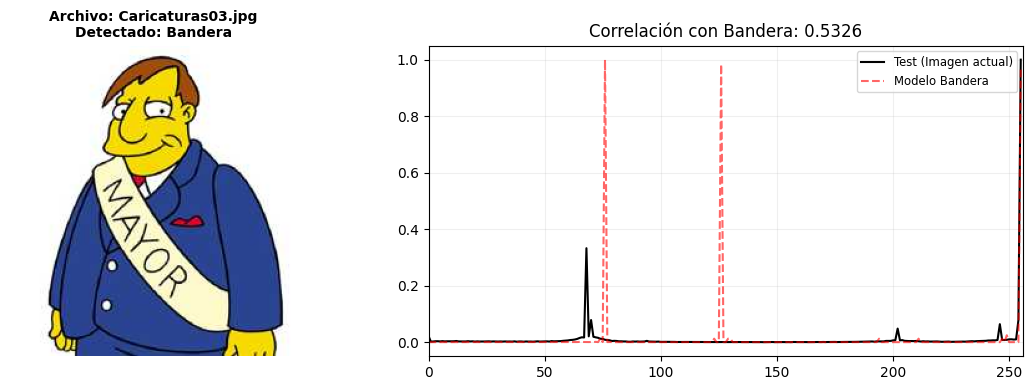

Puntajes para Caricaturas03.jpg: {'Bandera': 0.5326, 'Caricaturas': 0.2599, 'Paisaje': -0.0511, 'Personaje': -0.0206}
------------------------------------------------------------


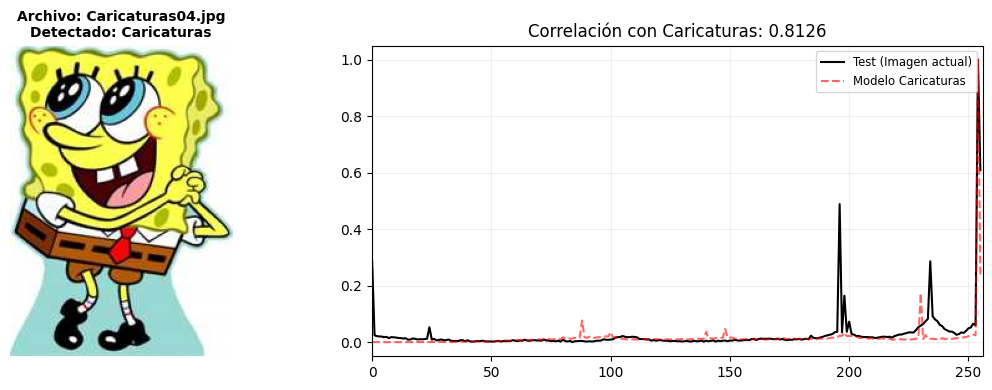

Puntajes para Caricaturas04.jpg: {'Bandera': 0.2328, 'Caricaturas': 0.8126, 'Paisaje': 0.0537, 'Personaje': -0.0222}
------------------------------------------------------------


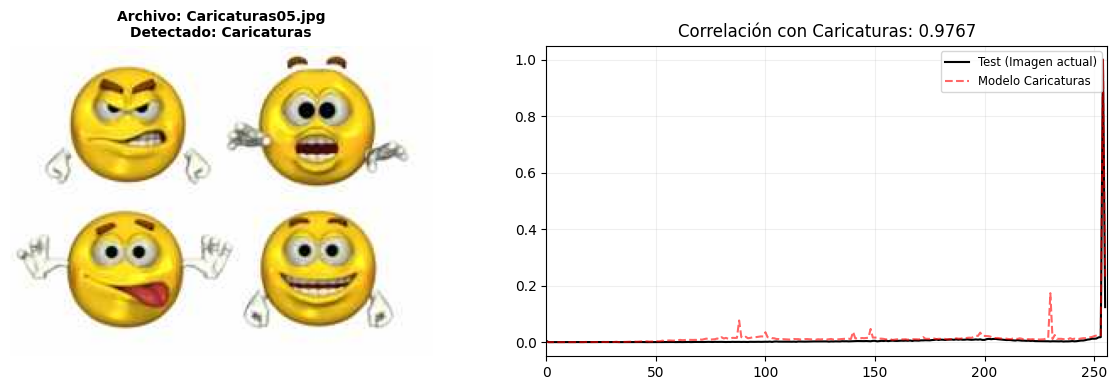

Puntajes para Caricaturas05.jpg: {'Bandera': 0.0588, 'Caricaturas': 0.9767, 'Paisaje': -0.0169, 'Personaje': -0.0245}
------------------------------------------------------------


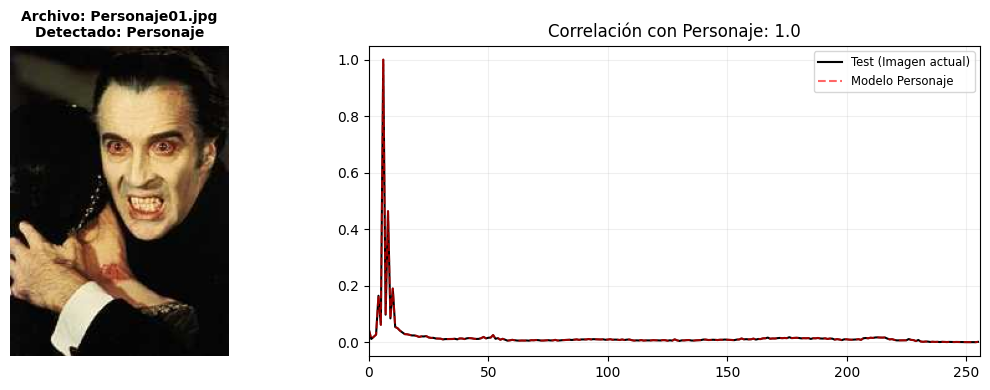

Puntajes para Personaje01.jpg: {'Bandera': -0.022, 'Caricaturas': -0.0434, 'Paisaje': -0.0737, 'Personaje': 1.0}
------------------------------------------------------------


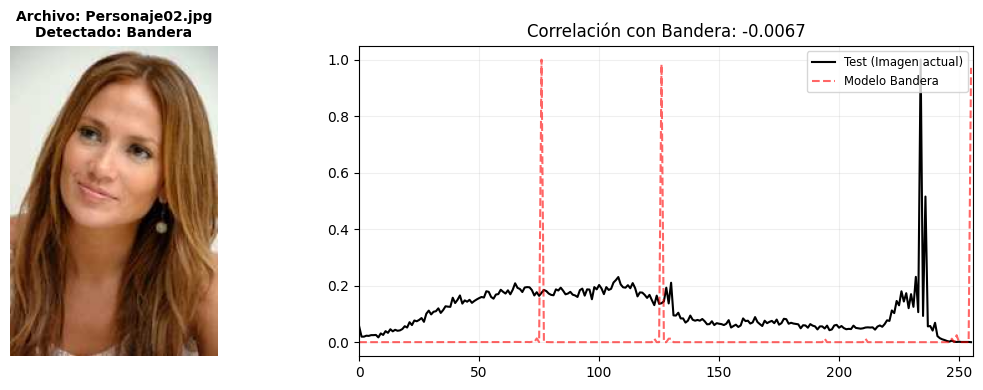

Puntajes para Personaje02.jpg: {'Bandera': -0.0067, 'Caricaturas': -0.0825, 'Paisaje': -0.2029, 'Personaje': -0.132}
------------------------------------------------------------


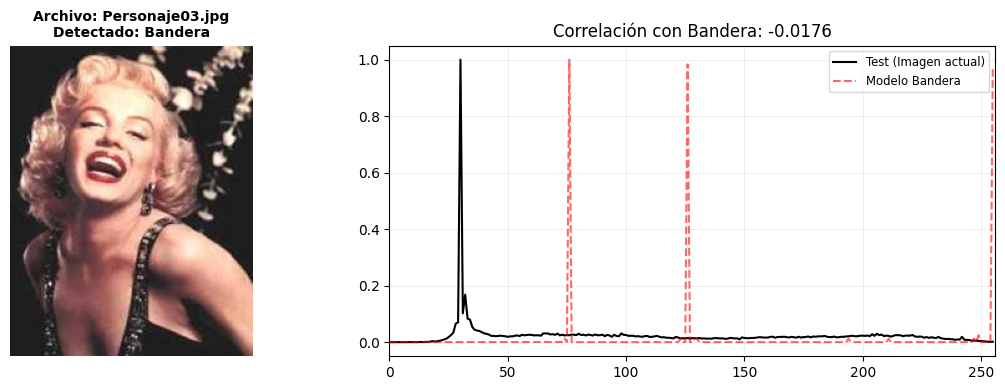

Puntajes para Personaje03.jpg: {'Bandera': -0.0176, 'Caricaturas': -0.0391, 'Paisaje': -0.0415, 'Personaje': -0.0418}
------------------------------------------------------------


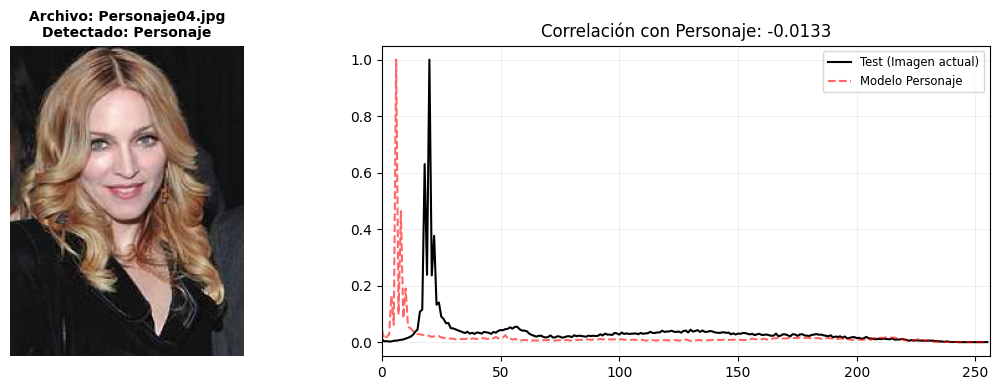

Puntajes para Personaje04.jpg: {'Bandera': -0.0262, 'Caricaturas': -0.0634, 'Paisaje': -0.0965, 'Personaje': -0.0133}
------------------------------------------------------------


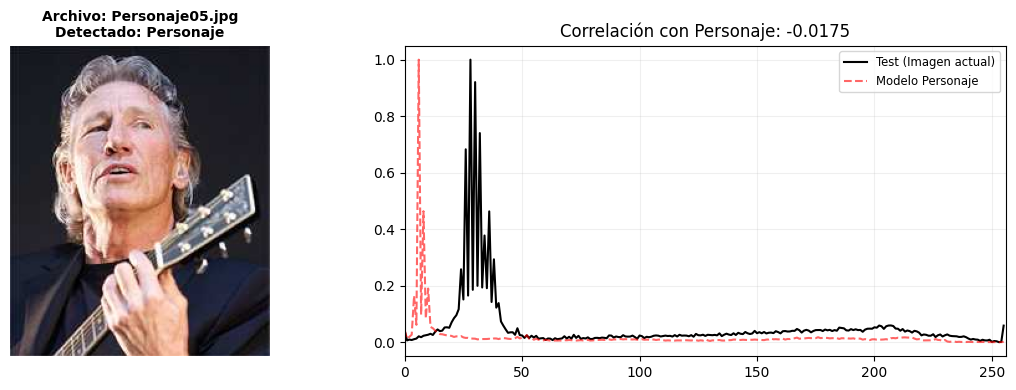

Puntajes para Personaje05.jpg: {'Bandera': -0.02, 'Caricaturas': -0.0606, 'Paisaje': -0.0867, 'Personaje': -0.0175}
------------------------------------------------------------


In [3]:
def calcular_hist_modelo(ruta):
    img = cv2.imread(ruta, cv2.IMREAD_GRAYSCALE)
    if img is None: return None
    hist = cv2.calcHist([img], [0], None, [256], [0, 256])
    cv2.normalize(hist, hist, alpha=0, beta=1, norm_type=cv2.NORM_MINMAX)
    return hist

# --- 1. CONFIGURACIÓN DE MODELOS ---
ruta_busqueda = '../../imagenes/Busqueda_histograma/' 
categorias = ['Bandera', 'Caricaturas', 'Paisaje', 'Personaje']
extension = '.jpg'

modelos = {}
for cat in categorias:
    archivo_modelo = f"{ruta_busqueda}{cat}01{extension}"
    modelos[cat] = calcular_hist_modelo(archivo_modelo)

# --- 2. FUNCIÓN DE CLASIFICACIÓN ---
def identificar_contenido(ruta_test):
    hist_test = calcular_hist_modelo(ruta_test)
    if hist_test is None: return "Error", {}, None

    mejor_score = -1
    categoria_ganadora = ""
    puntajes = {}

    for cat, hist_ref in modelos.items():
        if hist_ref is not None:
            score = cv2.compareHist(hist_ref, hist_test, cv2.HISTCMP_CORREL)
            puntajes[cat] = round(score, 4)
            if score > mejor_score:
                mejor_score = score
                categoria_ganadora = cat
                
    return categoria_ganadora, puntajes, hist_test

# --- 3. PROCESAR TODAS LAS IMÁGENES DE LA CARPETA ---
# Listamos todos los archivos en la carpeta que sean .jpg
archivos = [f for f in os.listdir(ruta_busqueda) if f.endswith(extension)]
archivos.sort() # Los ordenamos alfabéticamente

print(f"Se encontraron {len(archivos)} imágenes para procesar.\n")

for nombre_archivo in archivos:
    ruta_completa = os.path.join(ruta_busqueda, nombre_archivo)
    
    # Ejecutar clasificación
    resultado, todos_puntajes, h_test = identificar_contenido(ruta_completa)
    
    if resultado == "Error":
        continue

    # Visualización
    img_test = cv2.imread(ruta_completa)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # Subplot 1: Imagen
    ax1.imshow(cv2.cvtColor(img_test, cv2.COLOR_BGR2RGB))
    ax1.set_title(f"Archivo: {nombre_archivo}\nDetectado: {resultado}", fontsize=10, fontweight='bold')
    ax1.axis('off')

    # Subplot 2: Comparación de Histogramas
    ax2.plot(h_test, color='black', label='Test (Imagen actual)')
    ax2.plot(modelos[resultado], color='red', linestyle='--', alpha=0.6, label=f'Modelo {resultado}')
    ax2.set_title(f"Correlación con {resultado}: {todos_puntajes[resultado]}")
    ax2.set_xlim([0, 256])
    ax2.legend(loc='upper right', fontsize='small')
    ax2.grid(True, alpha=0.2)

    plt.tight_layout()
    plt.show()
    
    # Opcional: imprimir todos los puntajes por consola
    print(f"Puntajes para {nombre_archivo}: {todos_puntajes}\n" + "-"*60)